In [175]:
## IMPORTSimport pandas as pdimport numpy as npfrom sklearn.svm import SVCfrom sklearn.model_selection import GridSearchCV# visualizationimport seaborn as snsimport matplotlib.pyplot as plt

## Task 'A'

In [176]:
crash = pd.read_csv('crash.csv', index_col=0)crash.head()

,PassengerId,Survived,Class,Name,Sex,Age,Ticket Price,Safety
0,1,Didn't Survive,Economy,"Braund, Mr. Owen Harris",male,22.0,7.2500,0.336957
1,2,Survived,First Class,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,71.2833,0.553571
2,3,Survived,Economy,"Heikkinen, Miss. Laina",female,26.0,7.9250,0.336957
3,4,Survived,First Class,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,53.1000,0.336957
4,5,Didn't Survive,Economy,"Allen, Mr. William Henry",male,35.0,8.0500,0.336957


In [177]:
crash.dtypes

PassengerId       int64
Survived         object
Class            object
Name             object
Sex              object
Age             float64
Ticket Price    float64
Safety          float64
dtype: object

In [178]:
total = crash.isnull().sum().sort_values(ascending=False)percent = (crash.isnull().sum() / crash.isnull().count()).sort_values(ascending=False)missing_data = pd.concat([total, percent], axis=1, keys=["Total", 'Percent'])missing_data

,Total,Percent
Age,177,0.198653
Safety,2,0.002245
PassengerId,0,0.000000
Survived,0,0.000000
Name,0,0.000000
Class,0,0.000000
Sex,0,0.000000
Ticket Price,0,0.000000


to fill the missing 'age' data, we can just fill it with either the 'mean' or the 'median' of the non-missing ones.

im going with the 'mean'

In [179]:
crash['Age'] = crash['Age'].fillna(crash['Age'].mean())

In [180]:
total = crash.isnull().sum().sort_values(ascending=False)percent = (crash.isnull().sum() / crash.isnull().count()).sort_values(ascending=False)missing_data = pd.concat([total, percent], axis=1, keys=["Total", 'Percent'])missing_data

,Total,Percent
Safety,2,0.002245
PassengerId,0,0.000000
Class,0,0.000000
Survived,0,0.000000
Name,0,0.000000
Sex,0,0.000000
Age,0,0.000000
Ticket Price,0,0.000000


for the safety, i really don't know what it means, so i don't know what is the most appropriate method to fill its missing data.

though, since its only missing 2 values (which is less than 0.01 of its total) it shouldn't really matter that much.

In [181]:
crash.Safety.describe()

count    889.000000
mean       0.382452
std        0.083937
min        0.336957
25%        0.336957
50%        0.336957
75%        0.389610
max        0.553571
Name: Safety, dtype: float64

the margin for the data is really small, i could probably fill it with anything, so lets do what i did to the 'age'.

In [182]:
crash['Safety'] = crash['Safety'].fillna(crash['Safety'].mean())

now we dont have any missing values. lets transform our features into numerical ones

its pretty obviouse what we have to do with the 'sex' and 'survived' features, since theyre just binary. but what about the 'class' ?

In [183]:
crash.Class.unique().tolist()

['Economy', 'First Class', 'Business']

so we have 3 unique values for 'class' feature, we can use the same method as the 'sex' and 'survived' here.

In [184]:
crash['Sex'] = crash['Sex'].map({'male': 0, 'female': 1})crash['Survived'] = crash['Survived'].map({"Didn't Survive": 0, 'Survived': 1})crash['Class'] = crash['Class'].map({'Economy': 0, 'First Class': 1, 'Business': 2})

we only have one non-numerical feature left (Name), the name is probably is not going to play a significant role in the survival, so we can just remove it.

we also should remove the 'PassengerId' which adds nothing to our data.

In [185]:
crash = crash.drop(["Name", "PassengerId"], axis=1)

In [186]:
crash.head()

,Survived,Class,Sex,Age,Ticket Price,Safety
0,0,0,0,22.0,7.2500,0.336957
1,1,1,1,38.0,71.2833,0.553571
2,1,0,1,26.0,7.9250,0.336957
3,1,1,1,35.0,53.1000,0.336957
4,0,0,0,35.0,8.0500,0.336957


<Axes: >

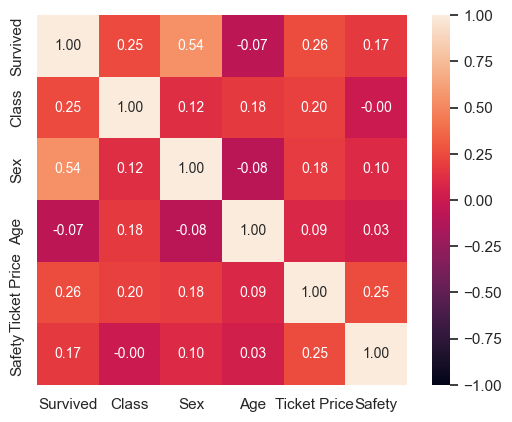

In [187]:
sns.heatmap(crash.corr(), annot=True, annot_kws={'size': 10}, fmt='.2f', square=True, vmax=1, vmin=-1)

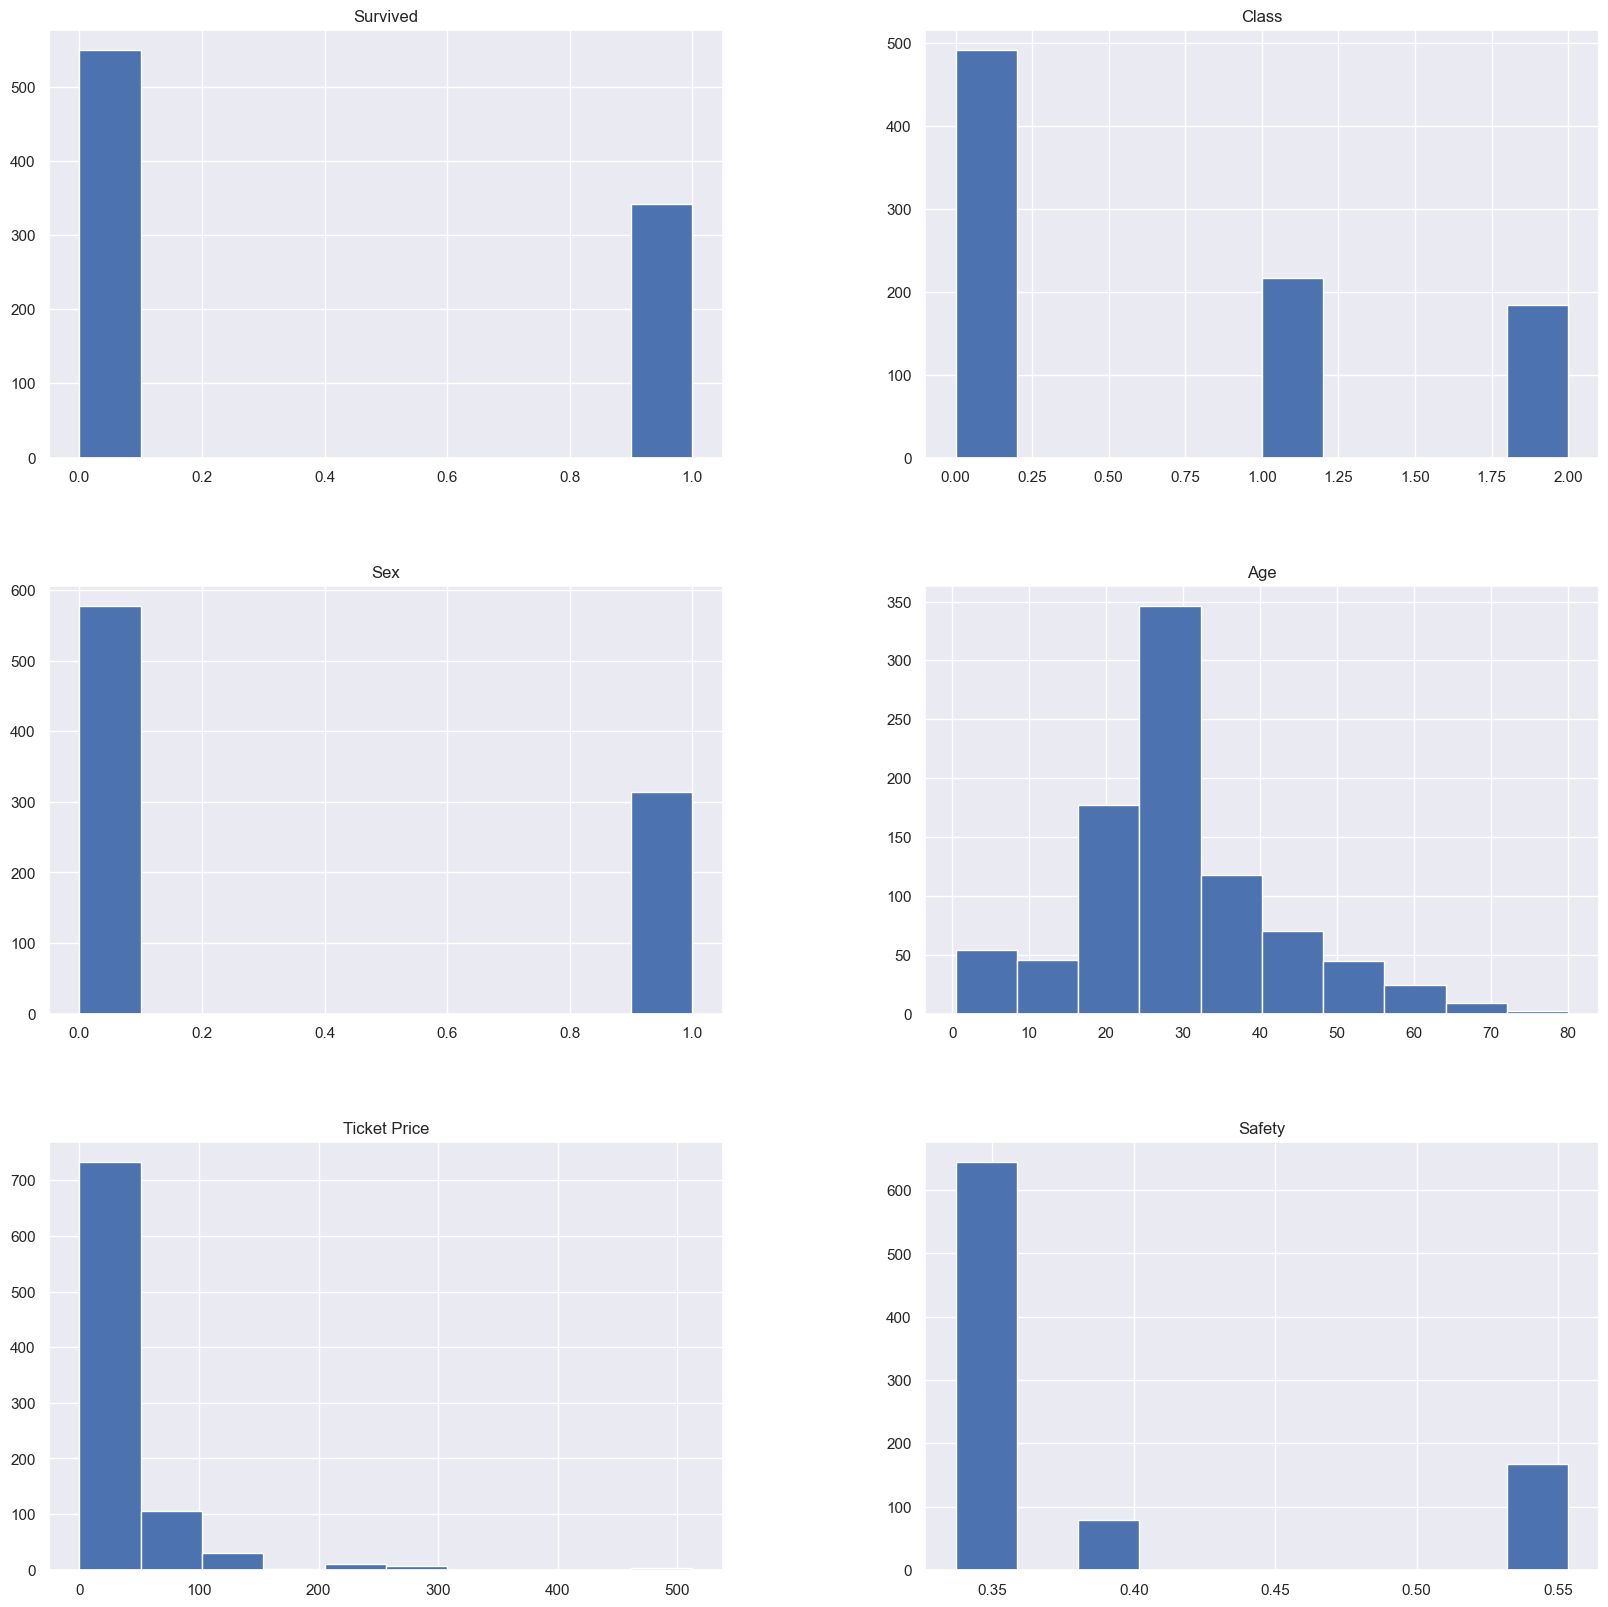

In [188]:
p = crash.hist(figsize = (20,20))

In [189]:
# sns.set_theme()# sns.pairplot(crash[crash.columns], height = 2.5)# plt.show()

## Task 'B'

lets first split the features from the labels

In [190]:
crash_label = crash['Survived']crash_features = crash.drop(['Survived'], axis=1)

In [191]:
# split the data:indices = list(range(crash_features.shape[0]))np.random.shuffle(indices)split_index = int(crash_features.shape[0] * 0.8)train_indices = indices[:split_index]test_indices = indices[split_index:]x_train, x_test = crash_features.iloc[train_indices], crash_features.iloc[test_indices]y_train, y_test = crash_label.iloc[train_indices], crash_label.iloc[test_indices]

## Task 'c'

with SVM from scratch:

In [192]:
class SVM:    def __init__(self, learning_rate=0.001, epochs=1000):        self.learning_rate = learning_rate        self.epochs = epochs    def initialize_parameters(self, dim, w=None, b=None):        self.w = np.zeros(dim) if w is None else w        self.b = 0 if b is None else b    def fit(self, X, y, initial_w=None, initial_b=None):        self.initialize_parameters(X.shape[1], w=initial_w, b=initial_b)        for epoch in range(1, self.epochs + 1):            for i in range(len(y)):                if y[i] * (np.dot(X[i], self.w) + self.b) < 1:                    self.w += self.learning_rate * (y[i] * X[i] - 2 * (1/epoch) * self.w)                    self.b += self.learning_rate * y[i]                else:                    self.w -= self.learning_rate * 2 * (1/epoch) * self.w    def predict(self, X):        return np.sign(np.dot(X, self.w) + self.b)

In [193]:
def compute_metrics(y_true, y_pred):    accuracy = np.mean(y_true == y_pred)    precision = np.sum((y_true == 1) & (y_pred == 1)) / np.sum(y_pred == 1)    recall = np.sum((y_true == 1) & (y_pred == 1)) / np.sum(y_true == 1)    print(f'Accuracy: {accuracy*100:.2f}%')    print(f'Precision: {precision*100:.2f}%')    print(f'Recall: {recall:.2f}')

In [194]:
x_train, x_test = x_train.values, x_test.valuesy_train, y_test = y_train.values.ravel(), y_test.values.ravel()

In [195]:
# Initialize and train the CustomSVMsvm = SVM(learning_rate=0.001, epochs=1000)svm.fit(x_train, y_train)# Predict and compute metricsy_pred = svm.predict(x_test)compute_metrics(y_test, y_pred)

Accuracy: 40.22%
Precision: 40.22%
Recall: 1.00


with the per-built sklearn class:

In [196]:
svm = SVC()svm.fit(x_train, y_train)y_pred_sklearn = svm.predict(x_test)# and the custom metric functioncompute_metrics(y_true=y_test, y_pred=y_pred_sklearn)

Accuracy: 68.72%
Precision: 76.67%
Recall: 0.32


## Task 'd'

In [22]:
# Define the grid paramsparam_grid = {    'C': [0.1, 1, 10, 100],    'gamma': [1, 0.1, 0.01, 0.001],    'kernel': ['linear', 'rbf']}# GridSearchCV objectgrid = GridSearchCV(SVC(), param_grid, verbose=2, cv=5)# Fit the grid searchgrid.fit(x_train, y_train)# the best parameters and estimatorprint(f'Best Parameters: {grid.best_params_}')print(f'Best Estimator: {grid.best_estimator_}')

Fitting 5 folds for each of 32 candidates, totalling 160 fits
[CV] END ......................C=0.1, gamma=1, kernel=linear; total time=   0.1s
[CV] END ......................C=0.1, gamma=1, kernel=linear; total time=   0.1s
[CV] END ......................C=0.1, gamma=1, kernel=linear; total time=   0.1s
[CV] END ......................C=0.1, gamma=1, kernel=linear; total time=   0.0s
[CV] END ......................C=0.1, gamma=1, kernel=linear; total time=   1.7s
[CV] END .........................C=0.1, gamma=1, kernel=rbf; total time=   0.0s
[CV] END .........................C=0.1, gamma=1, kernel=rbf; total time=   0.0s
[CV] END .........................C=0.1, gamma=1, kernel=rbf; total time=   0.0s
[CV] END .........................C=0.1, gamma=1, kernel=rbf; total time=   0.0s
[CV] END .........................C=0.1, gamma=1, kernel=rbf; total time=   0.0s
[CV] END ....................C=0.1, gamma=0.1, kernel=linear; total time=   0.1s
[CV] END ....................C=0.1, gamma=0.1, 

## Task 'e'

NOT A CODING TASK

## Task 'f'

In [23]:
# Predict using the best paramsy_pred_grid = grid.best_estimator_.predict(x_test)compute_metrics(y_true=y_test, y_pred=y_pred_grid)

Accuracy: 78.77%
Precision: 69.70%
Recall: 0.72
